In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import xgboost as xgb
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("reddit_features.csv")

In [3]:
df.columns

Index(['title', 'score', 'upvote_ratio', 'num_comments', 'created_utc',
       'subreddit', 'is_self', 'awards', 'url', 'post_hour', 'post_day',
       'is_weekend', 'title_words_count', 'has_question', 'has_number',
       'controversy_index', 'sentiment_score', 'is_extreme_sentiment', 'viral',
       'hf_sentiment', 'hf_sentiment_score'],
      dtype='object')

In [4]:
drop_cols = ["viral", "score", "awards", "url", "title", "subreddit", "num_comments", "hf_sentiment", "hf_sentiment_score", "created_utc"]

In [5]:
x = df.drop(columns=drop_cols)
y = df["viral"]

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 42)

In [7]:
model = xgb.XGBClassifier(scale_pos_weight=3)

In [8]:
model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [9]:
y_pred = model.predict(x_test)

In [10]:
print(accuracy_score(y_test, y_pred))

0.71


In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.81      0.81       151
           1       0.40      0.39      0.40        49

    accuracy                           0.71       200
   macro avg       0.60      0.60      0.60       200
weighted avg       0.71      0.71      0.71       200



In [12]:
print(confusion_matrix(y_test, y_pred))

[[123  28]
 [ 30  19]]


In [13]:
scores = cross_val_score(model, x, y, cv=5)
print(scores.mean())

0.6769999999999999


In [14]:
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=5
)

In [15]:
model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [16]:
y_prob = model.predict_proba(x_test)[:,1]
y_pred = (y_prob > 0.35).astype(int)

In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.60      0.71       151
           1       0.37      0.73      0.49        49

    accuracy                           0.63       200
   macro avg       0.62      0.67      0.60       200
weighted avg       0.75      0.63      0.66       200



In [18]:
x.columns

Index(['upvote_ratio', 'is_self', 'post_hour', 'post_day', 'is_weekend',
       'title_words_count', 'has_question', 'has_number', 'controversy_index',
       'sentiment_score', 'is_extreme_sentiment'],
      dtype='object')

In [19]:
model.feature_importances_

array([0.13367584, 0.20882525, 0.0887816 , 0.07137568, 0.        ,
       0.10844525, 0.03421985, 0.07425365, 0.141523  , 0.09934113,
       0.03955874], dtype=float32)

In [20]:
model_rf = RandomForestClassifier(class_weight="balanced")

In [21]:
model_rf.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced')

In [22]:
y_probrf = model_rf.predict_proba(x_test)[:,1]
y_predrf = (y_probrf > 0.35).astype(int)

In [23]:
print(classification_report(y_test, y_predrf))

              precision    recall  f1-score   support

           0       0.82      0.76      0.79       151
           1       0.39      0.47      0.43        49

    accuracy                           0.69       200
   macro avg       0.60      0.62      0.61       200
weighted avg       0.71      0.69      0.70       200



In [24]:
model_rf.feature_importances_

array([0.10521369, 0.01105814, 0.15012218, 0.07774908, 0.01574116,
       0.1746615 , 0.00413711, 0.02588392, 0.26092296, 0.15564138,
       0.01886888])

In [25]:
import joblib
joblib.dump(model, "xgb_model.pkl")

['xgb_model.pkl']

In [26]:
import shap

In [27]:
explainer = shap.TreeExplainer(model)

In [28]:
shap_values = explainer.shap_values(x_test)

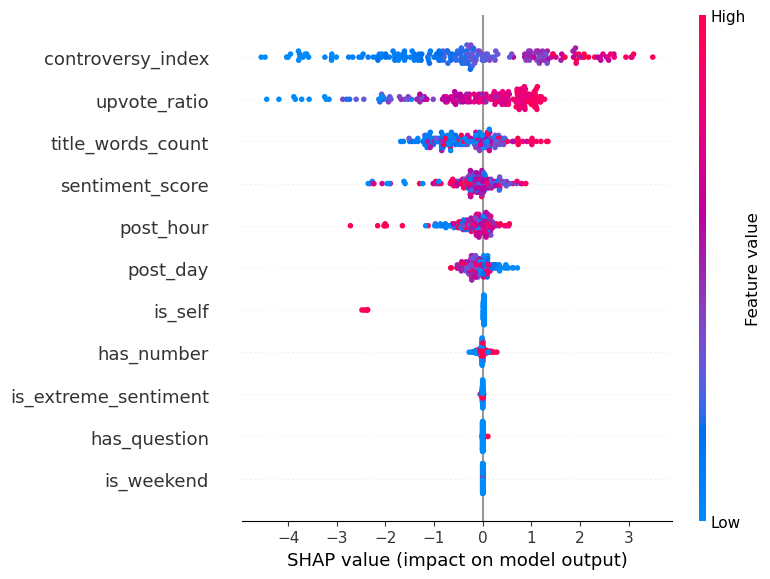

In [29]:
shap.summary_plot(shap_values, x_test)

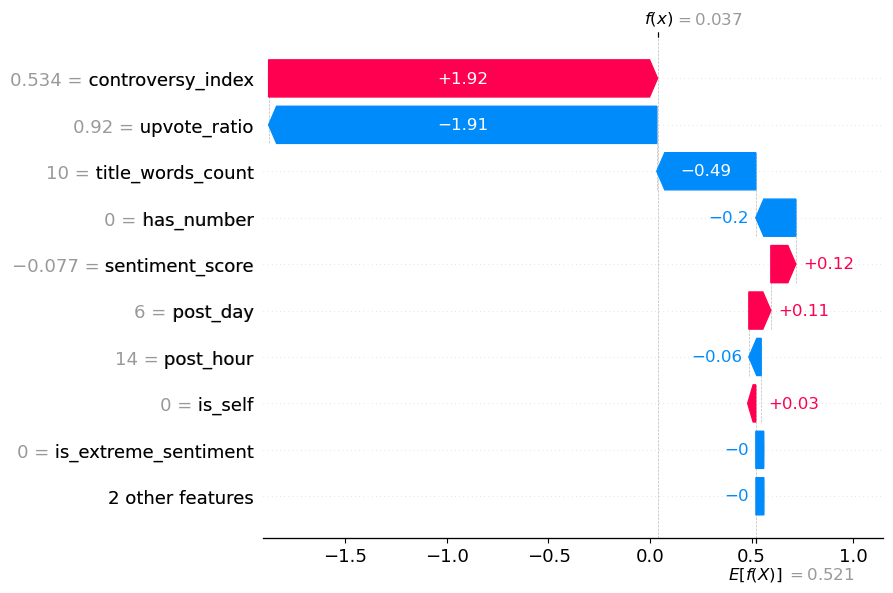

In [30]:
shap.plots.waterfall(explainer(x_test)[0])

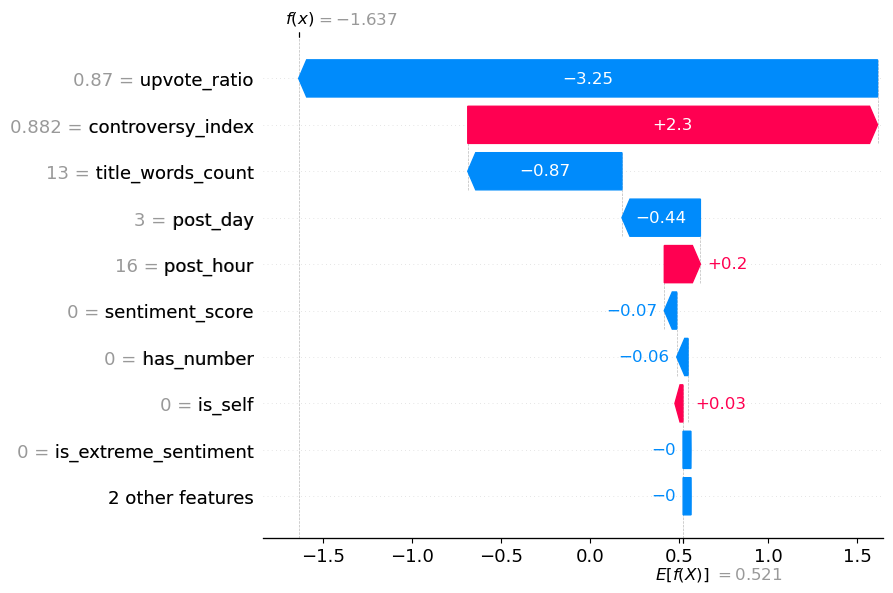

In [31]:
shap.plots.waterfall(explainer(x_test)[1])

- controversy_index is the most important feature for virality prediction
- SHAP waterfall plot shows instance-level explanation why a specific post was predicted viral or not
- High controversy + high upvote_ratio can contradict each other, making prediction non-viral

In [32]:
x.columns

Index(['upvote_ratio', 'is_self', 'post_hour', 'post_day', 'is_weekend',
       'title_words_count', 'has_question', 'has_number', 'controversy_index',
       'sentiment_score', 'is_extreme_sentiment'],
      dtype='object')

In [33]:
df.columns


Index(['title', 'score', 'upvote_ratio', 'num_comments', 'created_utc',
       'subreddit', 'is_self', 'awards', 'url', 'post_hour', 'post_day',
       'is_weekend', 'title_words_count', 'has_question', 'has_number',
       'controversy_index', 'sentiment_score', 'is_extreme_sentiment', 'viral',
       'hf_sentiment', 'hf_sentiment_score'],
      dtype='object')